In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
d=pd.read_csv("/content/drive/MyDrive/AI BATCH/Mall_Customers.csv")
d.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual_Income_(k$),0
Spending_Score,0


In [12]:
d.head()

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [13]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CustomerID          200 non-null    int64 
 1   Genre               200 non-null    object
 2   Age                 200 non-null    int64 
 3   Annual_Income_(k$)  200 non-null    int64 
 4   Spending_Score      200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [14]:
d.shape

(200, 5)

In [15]:
d.describe()

,CustomerID,Age,Annual_Income_(k$),Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


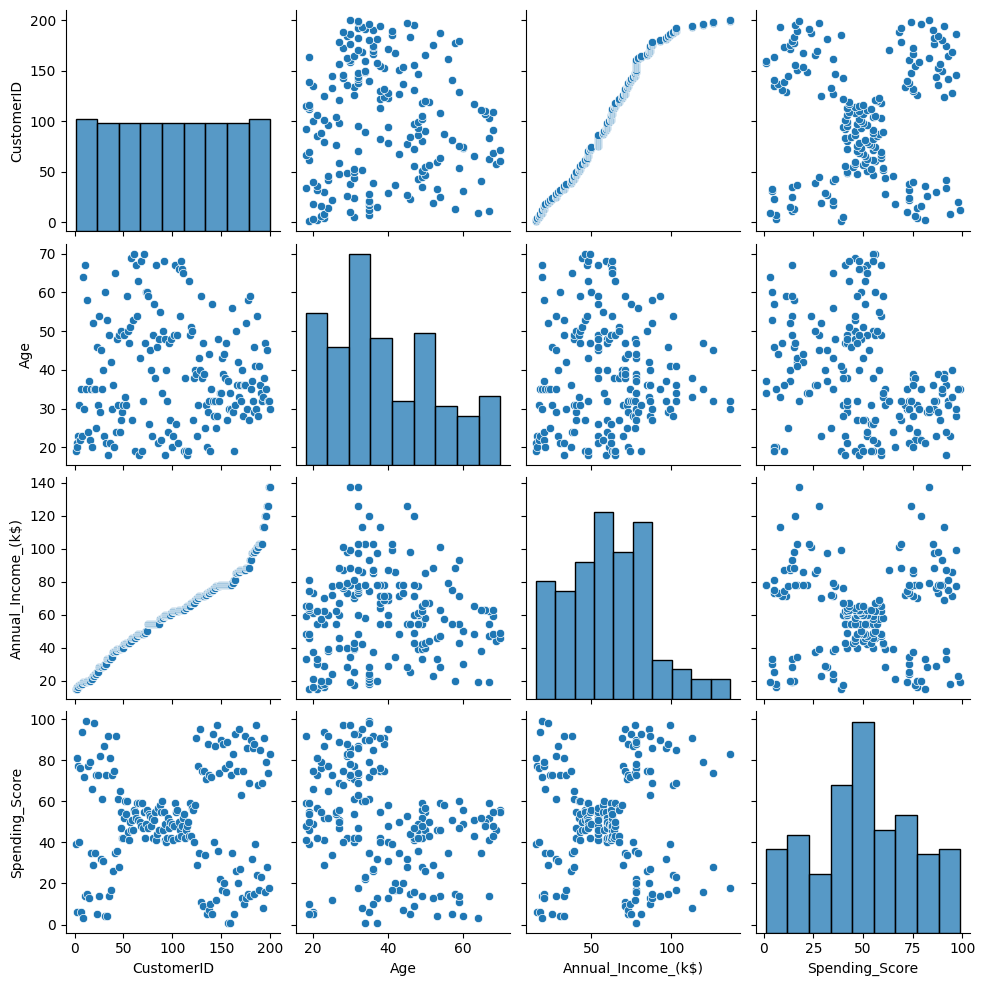

In [16]:
sns.pairplot(d)

In [18]:
cluster=d.iloc[:,2:].values

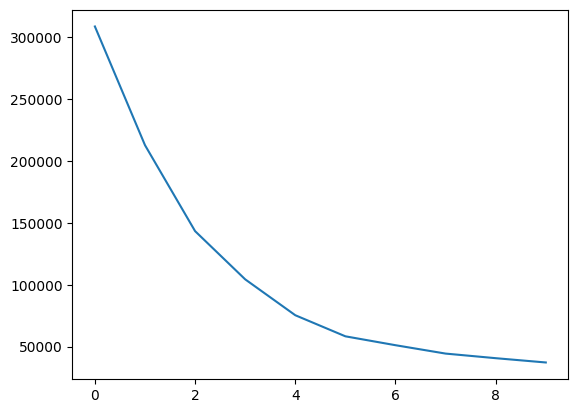

In [19]:
from sklearn.cluster import KMeans
c=[]
for i in range(1,11):
  model=KMeans(n_clusters=i, init="k-means++", random_state=0, n_init=10, max_iter=300)

  model.fit(cluster)
  c.append(model.inertia_)
plt.plot(c)

In [20]:

finamodel=KMeans(n_clusters=5, init="k-means++", random_state=0, n_init=10, max_iter=300)

label=finamodel.fit_predict(cluster)

In [21]:
label

array([0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 4, 1, 2, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 2, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1], dtype=int32)

In [22]:
finamodel.inertia_

75350.77917248776

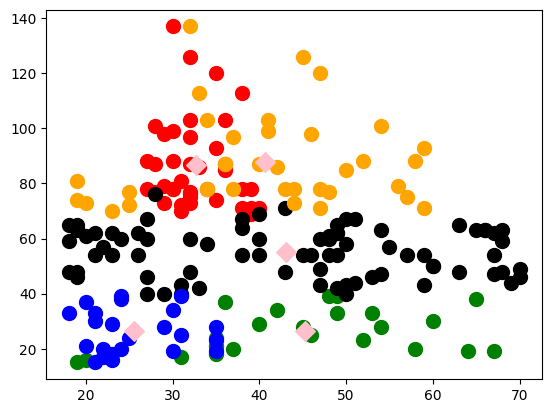

In [23]:
plt.scatter(cluster[label == 0, 0], cluster[ label == 0, 1], c='green', s=100, label='l1')
plt.scatter(cluster[label == 1, 0], cluster[ label == 1, 1], c='red', s=100, label='l2')
plt.scatter(cluster[label == 2, 0], cluster[ label == 2, 1], c='black', s=100, label='l3')
plt.scatter(cluster[label == 3, 0], cluster[ label == 3, 1], c='blue', s=100, label='l4')
plt.scatter(cluster[label == 4, 0], cluster[ label == 4, 1], c='orange', s=100, label='l5')

plt.scatter(finamodel.cluster_centers_[:,0], finamodel.cluster_centers_[:,1],c='pink', s=100, marker='D')
